# Purpose:
- Clustering based on multi-session coding scores.
- Going to be added to glm_analysis_tools

In [353]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from sklearn.cluster import SpectralClustering

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt
import seaborn as sns

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data
- cross-session normalization
- roicat df

In [5]:
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [22]:
session_ind_name_dict = {6: 'Familiar',
                         7: 'Novel',
                         8: 'Novel+1'}

In [183]:
roicat_df_fn = '/root/capsule/scratch/Thyme/roicat_df.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)
f1n2_session_inds = [6, 7, 8]
f1n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f1n2_session_inds) and matched')
f1n2_uc_series = f1n2_roi_df.groupby('unique_cell_name').size()
f1n2_matched_uc = f1n2_uc_series.index.values[np.where(f1n2_uc_series==len(f1n2_session_inds))[0]]
print(len(f1n2_matched_uc))
f1n2_all_matched_roi_df = f1n2_roi_df.query('unique_cell_name in @f1n2_matched_uc')
f1n2_all_matched_roi_df.head()

291


,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key_x,session_ind,unique_cell_name,cell_roi_id,valid_roi,exclusion_labels,touching_motion_border,small_roi,session_key_y,plane_session_key,session_key
roi_name,,,,,,,,,,,,,,,,,,,,
736963_2024-08-09_VISp_0_0005,5,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,5,88,db55ec77-70e9-4e64-8e7f-caa9660a4d5e,0.992339,0.976572,True,736963_2024-08-09,8,VISp_0_0088,5,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0007,7,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,7,101,f2aabcb6-bfb4-40ee-9ea1-e7f420475ab5,0.902556,1.000000,True,736963_2024-08-09,8,VISp_0_0101,7,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0008,8,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,8,98,fb45dc23-e4d5-4ebf-a5a9-b0c3c4eb36ff,0.982731,1.000000,True,736963_2024-08-09,8,VISp_0_0098,8,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0009,9,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,9,99,8483a820-9d1f-4576-ae40-7b868e611d9e,0.917262,1.000000,True,736963_2024-08-09,8,VISp_0_0099,9,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0010,10,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,10,3,127fcf28-5de9-480a-8218-3a5850abeaf5,0.985113,0.968638,True,736963_2024-08-09,8,VISp_0_0003,10,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09


In [9]:
f1n2_all_matched_roi_df.valid_roi.all()

True

In [222]:
dm_version = 1
data_type = 'events'
suffix = '00'

include_models = ['all-images', 'omissions', 'behavioral', 'task']

coding_score_table = f1n2_all_matched_roi_df.reset_index()[['roi_name', 'unique_cell_name', 'session_ind', 'session_key', 'fov_name', 'roi_session_index']].copy()

session_keys = np.sort(coding_score_table.session_key.unique())

coding_score_raw = None
for session_key in session_keys:
    session_matched_roi_name = ['_'.join(rn.split('_')[-3:]) for rn in f1n2_all_matched_roi_df.query(f'session_key=="{session_key}"').index.values]
    
    session_name = session_info_df.loc[session_key, 'session_name']
    session_ind = session_info_df.loc[session_key, 'session_ind']
    coding_score_fn = Path(glm_dir) / f'coding_score_736963_natural_images_v01_events/coding_score_v{dm_version:02}_{session_name}_{data_type}_{suffix}.nc'
    with xr.open_dataarray(coding_score_fn) as ds:
        coding_score_session = ds.expand_dims('session').assign_coords(session=[session_ind_name_dict[session_ind]])
        cell_roi_ids = coding_score_session.cell_roi_id.values
        
        # get filtered cell_roi_ids during glm fitting (<1% active frames)
        X, response, response_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_name, data_type, dm_version, load_path=glm_dir)
        response_trim = response[use_indices, :]
        response_trim_filtered = filter_response_matrix(response_trim)
        filtered_cell_roi_id = np.setdiff1d(response_trim.cell_roi_id.values, response_trim_filtered.cell_roi_id.values)
        
        # if there are missing cell_roi_ids among filtered cell_roi_ids, add them to coding_score_session and fill with 0
        missing_cell_roi_ids = np.setdiff1d(filtered_cell_roi_id, cell_roi_ids)
        if len(missing_cell_roi_ids) > 0:
            new_cell_roi_ids = np.concatenate([cell_roi_ids, missing_cell_roi_ids])
            coding_score_session = coding_score_session.reindex(cell_roi_id=new_cell_roi_ids, fill_value=0)
        
        # Choose only the matched cell_roi_ids
        coding_score_session = coding_score_session.sel(cell_roi_id=session_matched_roi_name, model=include_models).copy()
        
        # Swap cell_roi_id which is session-specific to unique_cell_name for concatenation across sessions
        unique_cell_names = []
        for cell_roi_id in coding_score_session.cell_roi_id.values:
            roi_name = f'{session_key}_{cell_roi_id}'
            unique_cell_names.append(f1n2_all_matched_roi_df.loc[roi_name, 'unique_cell_name'])

        coding_score_session = coding_score_session.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
        coding_score_session = coding_score_session.swap_dims({"cell_roi_id": "unique_cell_name"})
        coding_score_session = coding_score_session.reset_coords('cell_roi_id', drop=True)
    if coding_score_raw is None:
        coding_score_raw = coding_score_session
    else:
        coding_score_raw = xr.concat([coding_score_raw, coding_score_session], dim='session')
        
max_full_score = coding_score_raw.max(dim='session')
assert len(np.where(coding_score_raw.isnull())[0]) == 0

In [228]:
all_models = coding_score_raw.model.values
single_models = [m for m in all_models if m.startswith('single-')]
dropout_models = [m for m in all_models if 'single-' not in m]
assert len(single_models) + len(dropout_models) == len(all_models)

coding_score_normalized = xr.full_like(coding_score_raw.sel(metric='coding_score'), np.nan)

coding_score_normalized.loc[{'model': single_models}] = \
    -coding_score_raw.sel(model=single_models, metric='adj_ve_model') / max_full_score.sel(model=single_models, metric='adj_ve_full')
coding_score_normalized.loc[{'model': dropout_models}] = \
    -(1 - coding_score_raw.sel(model=dropout_models, metric='adj_ve_model') / max_full_score.sel(model=dropout_models, metric='adj_ve_full'))

# filtering
filter_threshold = 0.005
mask_from_max = max_full_score.sel(metric='adj_ve_full') < filter_threshold
sessions = coding_score_raw.session.values
mask_from_max = xr.concat([mask_from_max] * len(sessions), dim="session")
mask_from_max = mask_from_max.assign_coords(session=sessions)
mask_from_raw = coding_score_raw.sel(metric='adj_ve_model') < filter_threshold

coding_score_normalized_filtered = coding_score_normalized.where(~(mask_from_max + mask_from_raw), other=0)

# clipping
coding_score_normalized_filtered_clipped = coding_score_normalized_filtered.clip(min=-1, max=0)
assert len(np.where(coding_score_normalized_filtered_clipped.isnull())[0]) == 0

### NaN issue
- It's not from nonactive neurons
- It was because of using session cell_roi_id instead of unique_cell_name
- Also there were filtered rois that need to be included with 0 ve and coding scores
- Lastly, cells should have been filtered based on matching from roicat_df

In [229]:
coding_score_novelty = coding_score_normalized_filtered_clipped.sel(model=['all-images', 'behavioral', 'task', 'omissions'])
coding_score_novelty_df = coding_score_novelty.to_dataframe().reset_index()

In [232]:
coding_score_novelty_df

,session,model,unique_cell_name,metric,coding_score_metrics_from_session_model
0,Familiar,all-images,VISp_0_0003,coding_score,-0.775445
1,Familiar,all-images,VISp_0_0007,coding_score,-0.866331
2,Familiar,all-images,VISp_0_0009,coding_score,-0.472545
3,Familiar,all-images,VISp_0_0010,coding_score,-0.582893
4,Familiar,all-images,VISp_0_0024,coding_score,-0.867529
...,...,...,...,...,...
3487,Novel+1,omissions,VISp_7_0116,coding_score,-0.481733
3488,Novel+1,omissions,VISp_7_0117,coding_score,-0.183339
3489,Novel+1,omissions,VISp_7_0121,coding_score,-0.257079
3490,Novel+1,omissions,VISp_7_0125,coding_score,-0.029280


In [230]:
coding_score_table['experience'] = coding_score_table.session_ind.map(session_ind_name_dict)
coding_score_table

,roi_name,unique_cell_name,session_ind,session_key,fov_name,roi_session_index,experience
0,736963_2024-08-09_VISp_0_0005,VISp_0_0088,8,736963_2024-08-09,VISp_0,5,Novel+1
1,736963_2024-08-09_VISp_0_0007,VISp_0_0101,8,736963_2024-08-09,VISp_0,7,Novel+1
2,736963_2024-08-09_VISp_0_0008,VISp_0_0098,8,736963_2024-08-09,VISp_0,8,Novel+1
3,736963_2024-08-09_VISp_0_0009,VISp_0_0099,8,736963_2024-08-09,VISp_0,9,Novel+1
4,736963_2024-08-09_VISp_0_0010,VISp_0_0003,8,736963_2024-08-09,VISp_0,10,Novel+1
...,...,...,...,...,...,...,...
868,736963_2024-08-06_VISp_7_0084,VISp_7_0085,6,736963_2024-08-06,VISp_7,84,Familiar
869,736963_2024-08-06_VISp_7_0086,VISp_7_0091,6,736963_2024-08-06,VISp_7,86,Familiar
870,736963_2024-08-06_VISp_7_0087,VISp_7_0073,6,736963_2024-08-06,VISp_7,87,Familiar
871,736963_2024-08-06_VISp_7_0088,VISp_7_0087,6,736963_2024-08-06,VISp_7,88,Familiar


In [233]:
set(coding_score_table.unique_cell_name.unique()) == set(coding_score_novelty_df.unique_cell_name.unique())

True

In [235]:
for model in include_models:
    coding_score_table[model] = coding_score_table.apply(lambda x: coding_score_novelty_df.query(f'model=="{model}" and session=="{x.experience}" and unique_cell_name=="{x.unique_cell_name}"').coding_score_metrics_from_session_model.values[0], axis=1)
assert len(np.where(coding_score_table[include_models].isnull().values)[0]) == 0

In [248]:
feature_table = coding_score_table.pivot(index='unique_cell_name', columns='experience', values=include_models)
feature_table

all-images                     omissions                      \
experience         Familiar     Novel   Novel+1  Familiar     Novel   Novel+1   
unique_cell_name                                                                
VISp_0_0003       -0.775445 -0.649337 -0.755035 -0.532214 -0.170559 -0.699361   
VISp_0_0007       -0.866331 -0.517923 -0.772568 -0.598659 -0.217843 -0.753454   
VISp_0_0009       -0.472545 -0.182029 -0.519507 -0.314845 -0.214475 -0.433400   
VISp_0_0010       -0.582893 -0.257704 -0.506404 -0.631319 -0.078626 -0.494445   
VISp_0_0024       -0.867529 -0.445338 -0.727154 -0.772548 -0.122419 -0.628543   
...                     ...       ...       ...       ...       ...       ...   
VISp_7_0116       -0.769579 -0.747832 -0.480588 -0.145164 -0.392256 -0.481733   
VISp_7_0117       -0.588201 -0.183627 -0.123360 -0.631240 -0.120648 -0.183339   
VISp_7_0121       -0.551720 -0.473480 -0.144413 -0.256384 -0.347699 -0.257079   
VISp_7_0125       -0.706580 -0.825411 -0.568626 -0.008790 -0.675834 -0.029280   
VISp_7_0140       -0.563790 -0.547005 -0.493000 -0.499482 -0.224642 -0.140139   

                 behavioral                          task                      
experience         Familiar     Novel   Novel+1  Familiar     Novel   Novel+1  
unique_cell_name                                                               
VISp_0_0003       -0.584884 -0.069958 -0.662987 -0.751132 -0.302570 -0.721283  
VISp_0_0007       -0.621680 -0.166223 -0.810481 -0.809121 -0.251969 -0.802767  
VISp_0_0009       -0.955278 -0.541085 -0.803089 -0.837838 -0.249145 -0.523889  
VISp_0_0010       -0.948012 -0.692994 -0.892421 -0.566782 -0.079882 -0.625257  
VISp_0_0024       -0.825673 -0.094871 -0.662023 -0.828288 -0.332563 -0.700579  
...                     ...       ...       ...       ...       ...       ...  
VISp_7_0116       -0.350725 -0.107505 -0.644992 -0.692382 -0.077972 -0.604003  
VISp_7_0117       -0.886662 -0.607766 -0.802161 -0.683608 -0.307916 -0.728852  
VISp_7_0121       -0.695821 -0.813354 -0.667927 -0.423285 -0.585720 -0.282013  
VISp_7_0125       -0.211369 -0.379581 -0.232593 -0.331095 -0.327533 -0.306936  
VISp_7_0140       -0.606561 -0.253570 -0.505431 -0.667136 -0.291389 -0.351418  

[291 rows x 12 columns]

In [316]:
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

In [315]:
feature_table_fn = '/root/capsule/scratch/Thyme/clustering/feature_table_fnn.pkl'
feature_table.to_pickle(feature_table_fn)

In [249]:
feature_table.columns.levels[0]

Index(['all-images', 'omissions', 'behavioral', 'task'], dtype='object')

# Optimal number of clusters

## Gap statistics

In [256]:
metric = 'euclidean' # default distance metric
shuffle_type ='all' # default shuffle type is all shuffle (cell id and regressors)
k_max = 50 #max number of clusters to test

sc = SpectralClustering()
gap_df = vba_tools.compute_gap(clustering=sc, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

In [258]:
gap_df.keys()

dict_keys(['gap', 'reference_inertia', 'ondata_inertia', 'reference_sem', 'ondata_sem', 'gap_mean', 'gap_sem'])

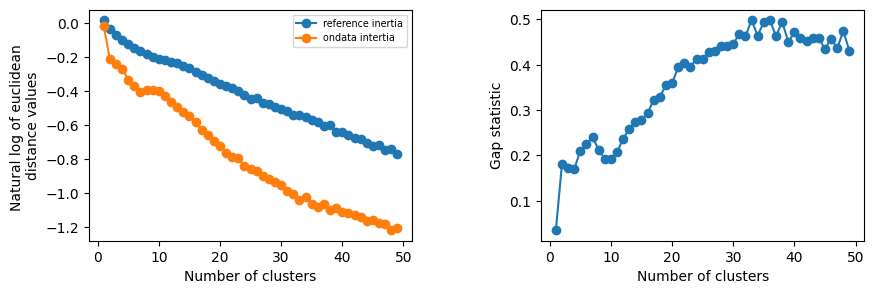

In [261]:
vba_tools.plot_gap_statistic(gap_df)

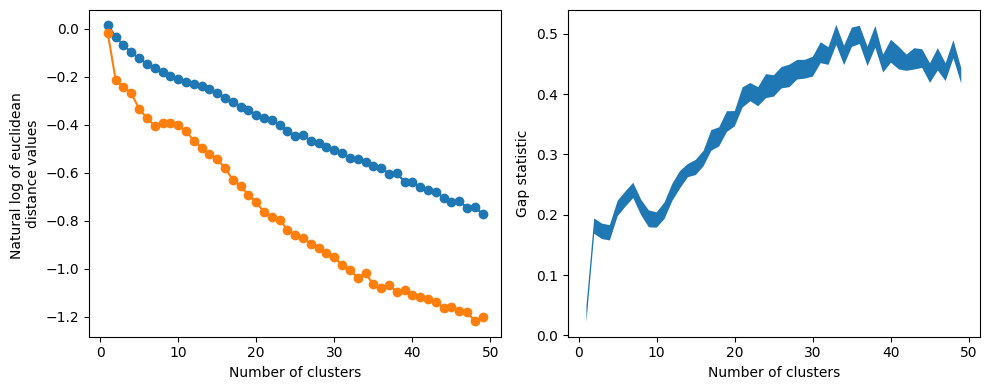

In [275]:
vba_tools.plot_gap_statistic_with_sem(gap_df)

In [277]:
gap_save_fn = Path(glm_dir) / f'clustering/gap_{dm_version:02}_{data_type}_{suffix}.npy'
gap_save_fn.parent.mkdir(parents=True, exist_ok=True)
np.save(gap_save_fn, gap_df)

# Low dimensional embedding
- PCA
- UMAP

Text(0, 0.5, 'cumulative explained variance')

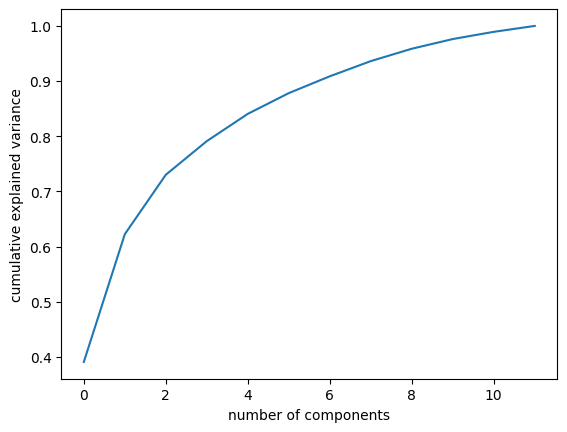

In [281]:
# PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(feature_table.values)
# show the results
fig, ax = plt.subplots()
ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative explained variance')

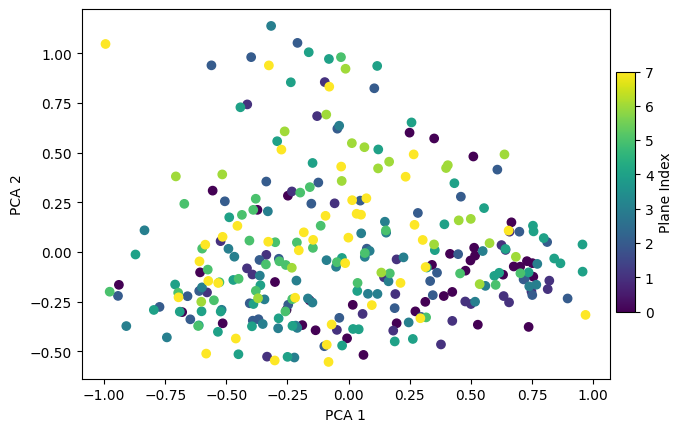

In [322]:
# show embedding
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

fig, ax = plt.subplots()
feature_table_pca = pca.transform(feature_table.values)
ax.scatter(feature_table_pca[:, 0], feature_table_pca[:, 1], c=feature_table_with_info['plane_ind'], cmap='viridis')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.25, 0.03, 0.5])
cbar = fig.colorbar(ax.collections[0], cax=cbar_ax)
cbar.set_label('Plane Index')


In [329]:
# Show in interactive 3D using plotly
import plotly.graph_objs as go
fig = go.Figure(data=[go.Scatter3d(x=feature_table_pca[:, 0],
                                   y=feature_table_pca[:, 1],
                                   z=feature_table_pca[:, 2],
                                   mode='markers',
                                   marker=dict(size=4,
                                               color=feature_table_with_info['plane_ind'],
                                               colorscale='viridis',
                                               opacity=1))])

# Set plot layout
fig.update_layout(scene=dict(
    xaxis_title="PC 1",
    yaxis_title="PC 2",
    zaxis_title="PC 3"
))

fig.update_layout(
    height=800  # Set the height
)

fig.show()


In [308]:
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



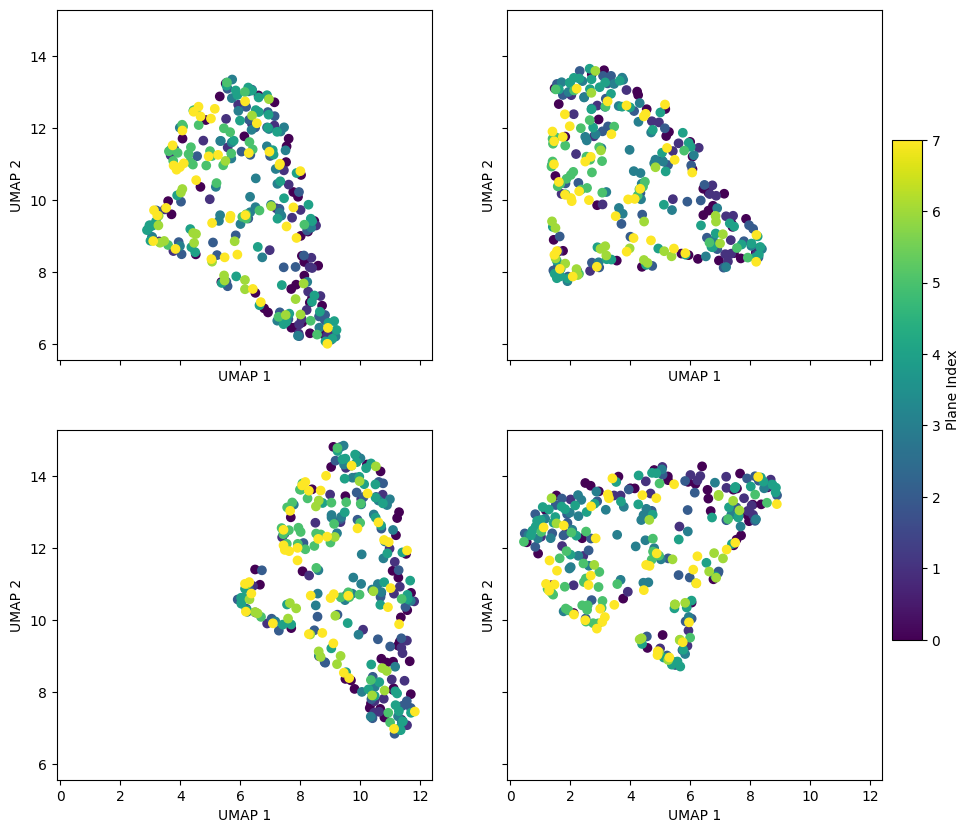

In [314]:
# show feature_table data in UMAP
import umap
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10,10))
for i in range(4):
    ix, iy = i//2, i%2
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(feature_table.values)
    
    ax[iy, ix].scatter(embedding[:, 0], embedding[:, 1], c=feature_table_with_info['plane_ind'].values)
    ax[iy, ix].set_xlabel('UMAP 1')
    ax[iy, ix].set_ylabel('UMAP 2')
# add a colorbar by adding a space to the right of the figure
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.25, 0.03, 0.5])
cbar = fig.colorbar(ax[0,0].collections[0], cax=cbar_ax)
cbar.set_label('Plane Index')


In [330]:
# hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering()
gap_df_hc = vba_tools.compute_gap(clustering=hc, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

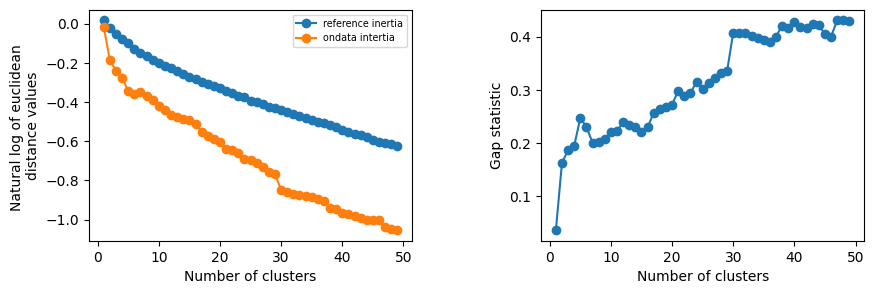

In [331]:
vba_tools.plot_gap_statistic(gap_df_hc)

In [350]:
hc.fit(feature_table.values)

AgglomerativeClustering(n_clusters=49)

In [351]:
hc.labels_

array([19, 16,  4, 44, 13, 46, 24, 30, 28, 37, 44,  4,  0, 16, 43, 22,  2,
       38,  0,  4, 24,  0, 27, 34, 20,  0,  0,  5, 10, 16, 21,  2, 41,  4,
       43, 44, 16,  2,  2,  8,  2,  9, 32, 47, 13,  2,  0,  2, 36, 20,  4,
        0, 28, 18, 17,  4, 16, 23, 28,  4, 16, 44,  0, 25, 28, 13, 24,  2,
       15, 30,  1, 48, 25, 16, 21, 11, 18, 16,  2, 34,  2,  7,  0, 12, 25,
       17,  0, 25, 16, 41, 22, 14, 24,  7, 12,  0, 31, 36,  9, 30,  4,  6,
       24, 13, 11, 33, 36, 22, 34, 44, 11, 21, 18, 15, 28, 11,  0, 25, 24,
       43,  2, 11, 35, 18, 21, 28, 35, 35, 13, 10,  4, 28,  8, 35, 16, 13,
       11, 22, 21, 11, 21,  4, 25,  0, 19,  0, 24,  1, 44, 25, 48,  6, 13,
        4, 11, 20, 39, 31, 30, 38, 11, 24, 48, 47, 19,  4, 19,  4, 11,  1,
       25, 31, 33, 13, 28, 38, 20,  0, 24, 34, 21, 31, 41, 13, 11,  0, 19,
       24, 31, 33, 27, 43, 19,  8, 14, 22, 32, 17, 32, 32, 24,  3, 22, 17,
       21,  0, 25,  0,  2,  8, 22, 32, 17,  8,  5, 34,  5, 22,  8, 10, 17,
       21, 29,  4, 21, 35

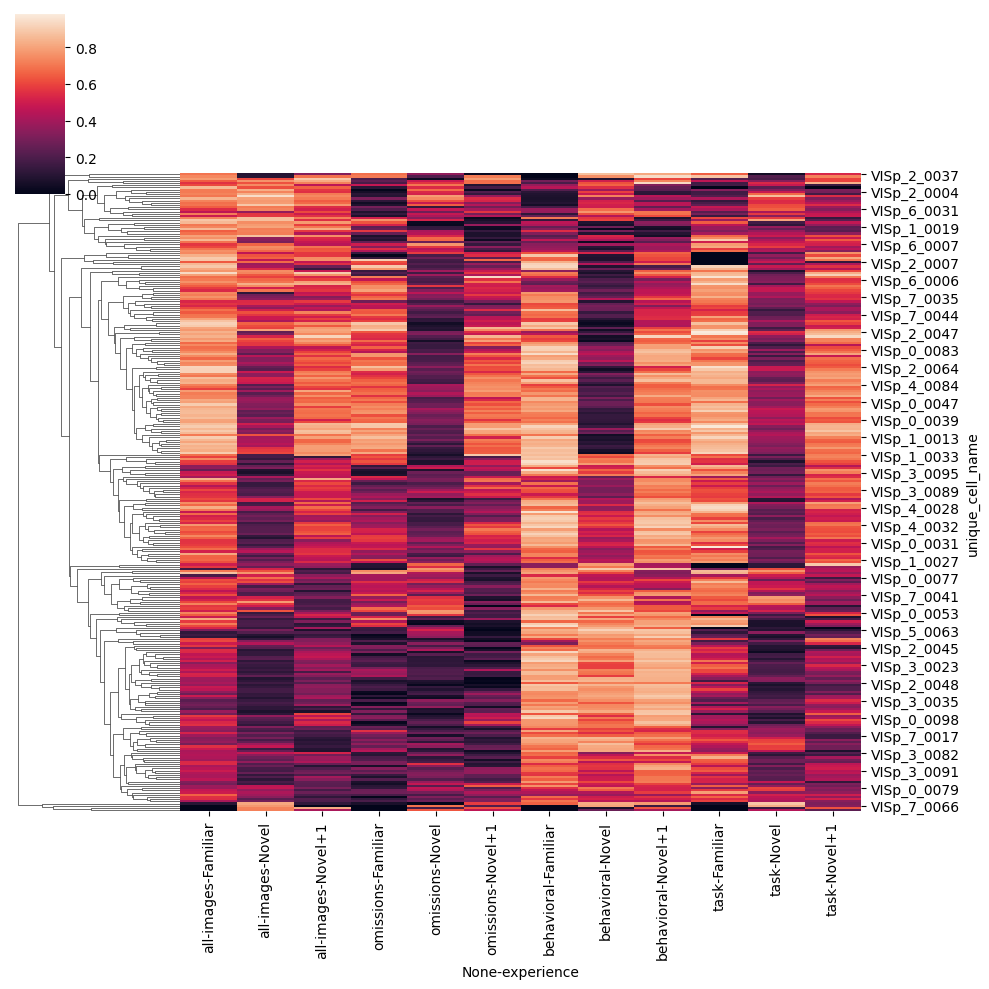

In [358]:

sns.clustermap(-feature_table, row_cluster=True, col_cluster=False)

# Novelty coding score issue
- More cells show novelty-suppressed.
- This is in contrast with previous GAD2;Ai195 data.
    - Need to validate coding scores

In [332]:
# dbscan clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN()
gap_df_dbscan = vba_tools.compute_gap(clustering=dbscan, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

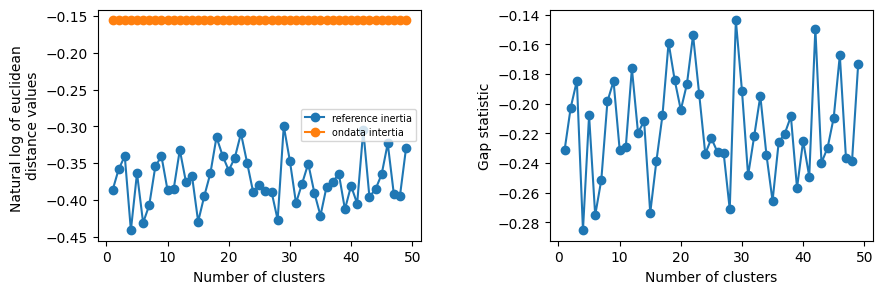

In [334]:
vba_tools.plot_gap_statistic(gap_df_dbscan)

In [333]:
# optics clustering
from sklearn.cluster import OPTICS
optics = OPTICS()
gap_df_optics = vba_tools.compute_gap(clustering=optics, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

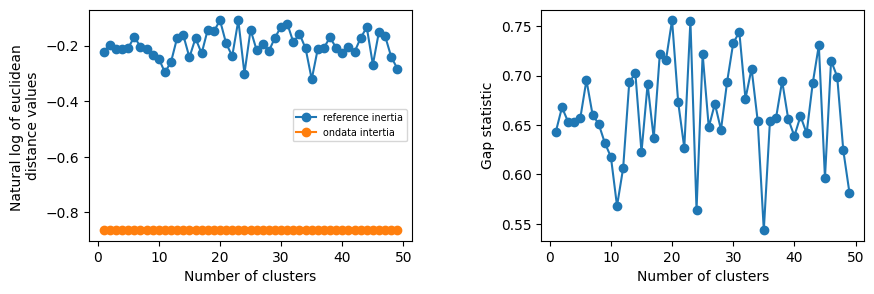

In [335]:
vba_tools.plot_gap_statistic(gap_df_optics)

In [348]:
optics = OPTICS(min_samples=3, xi=0.0001).fit(feature_table.values)

In [349]:
len(np.where(optics.labels_==-1)[0])

194

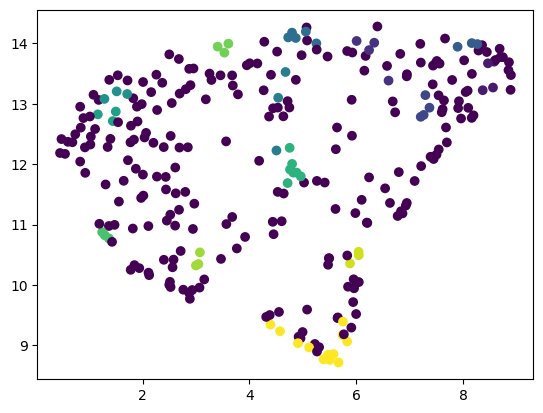

In [340]:
fig, ax = plt.subplots()
ax.scatter(embedding[:, 0], embedding[:, 1], c=optics.labels_, cmap='viridis')